Index Inclusion Strategy (Trading the Index Effect)
======

When a stock is added to a major equity index, every index fund and closet benchmarker
tracking that index _must_ buy it, more or less regardless of price, by the day the change
becomes effective. Stocks deleted from an index face the mirror-image forced selling.
The resulting price pressure is known as the **index effect**:
additions tend to gain a few percent between the announcement and the effective date,
while deletions tend to lose a few.

The effect is one of the oldest documented "anomalies": Shleifer (1986) and
Harris & Gurel (1986) both measured abnormal returns of around +3% on S&P 500 additions.
[Greenwood & Sammon (2025)](https://www.nber.org/papers/w30748) tally the whole history:
S&P 500 additions earned an average abnormal return of **+3.4% in the 1980s and
+7.4% in the 1990s** between announcement and effective day, decaying to **well under +1%
in the 2010s** as arbitrageurs crowded in (deletions show the same pattern with opposite
sign). The effect survives more strongly outside US mega caps — in smaller indices,
and in indices where changes are harder to anticipate.

Here is the interesting part for us: many indices are **purely mechanical**. Membership
follows published rules applied to public data — market-cap ranks on a known date —
so a careful observer can compute _today_ which stocks are about to be added,
**before the index provider announces anything**. That is the strategy this tutorial builds:

1. study the actual rulebooks of a few real indices,
2. re-implement one mechanical rulebook on a (synthetic) point-in-time market,
3. screen weekly — with look-ahead bias carefully removed — for stocks that have just
   become eligible for inclusion,
4. buy **one stock at a time**, and be out again within **at most a month** —
   after the index trackers have done their buying.

_This is an educational example, not investment advice. In heavily arbitraged markets
(US large caps in particular), most of this edge has already been competed away._

Real index rulebooks
--------------------

The rules below are condensed from the providers' methodology documents
(as of mid-2026; thresholds are updated regularly):

* **[S&P 500](https://en.wikipedia.org/wiki/S%26P_500)** — the least mechanical of the lot:
  a committee picks constituents from an eligibility pool. The published gates:
  US domicile and listing, unadjusted market cap above a quarterly-reviewed minimum
  ($22.7 billion since the July 2025 update), **positive GAAP earnings in the most recent
  quarter _and_ summed over the trailing four quarters**, at least 10% of shares floating,
  and annual traded value of at least 0.75× float-adjusted cap. Additions are announced
  only days before they take effect, but the earnings gate makes "newly eligible" stocks
  easy to shortlist — famously, Tesla rallied ~60% between its November 2020
  announcement and its December 21 effective date.
* **[Nasdaq-100](https://en.wikipedia.org/wiki/Nasdaq-100)** — mechanical: the 100 largest
  non-financial companies listed exclusively on Nasdaq. At the December reconstitution,
  ranks are set from market caps on the last trading day of November: the **top 75 by rank
  are added automatically**, current members ranked up to 100 are retained, and members
  ranked 101–125 may hang on only if they were in the top 100 a year earlier. Changes are
  announced mid-December and take effect before the open on the Monday after the third
  Friday. Because the ranking date and formula are public, the December 2024 additions
  (Palantir, MicroStrategy, Axon) were correctly "predicted" by analysts weeks in advance.
  Since 2026 the index also runs rank-based quarterly reviews in March, June and September.
* **[Russell 1000/2000/3000](https://en.wikipedia.org/wiki/Russell_2000_Index)** — fully
  mechanical, no committee at all: every US stock is ranked by total market cap on
  **"Rank Day" (April 30)**; the top 1000 form the Russell 1000, the next 2000 the
  Russell 2000, with a ±2.5% band around the breakpoint to limit churn. Preliminary
  add/delete lists are published in late May, and the new indices go live after the close
  of the fourth Friday of June — historically one of the highest-volume trading days of
  the year. (From 2026 the reconstitution is semi-annual, adding a November round.)
* **[FTSE 100](https://en.wikipedia.org/wiki/FTSE_100_Index)** — mechanical and refreshingly
  simple. At each quarterly review (March/June/September/December), companies are ranked by
  full market cap using prices at the close of the **Tuesday before the first Friday** of the
  review month: any non-member ranked **90th or better is added automatically**; any member
  ranked **111th or worse is dropped automatically** (the 90/111 buffer prevents stocks from
  flip-flopping across rank 100); the count is then topped back up to exactly 100.
  Changes are announced the next day and take effect after the close of the third Friday.

| Index | Basis | Add / drop trigger | Reviews | Predictable in advance? |
|:--|:--|:--|:--|:--|
| S&P 500 | committee + gates | cap ≥ $22.7B, GAAP profits, float, liquidity | quarterly + ad hoc | partly (eligibility watchlists) |
| Nasdaq-100 | cap rank | top 75 in; members keep to 100; 101–125 conditional | annual Dec (+ quarterly) | yes, from public ranks |
| Russell 1000/2000 | cap rank | breakpoint ± 2.5% band | June (+ Nov since 2026) | yes, from public ranks |
| FTSE 100 | cap rank | ≤ 90 in, ≥ 111 out | quarterly | yes, from public ranks |

The rank-based rulebooks are the exploitable ones: between a review's **data cutoff** and its
**effective date** lies a window of one to several weeks in which the coming additions are
either already computable (after the cutoff) or forecastable with high confidence (shortly
before it, for stocks comfortably inside the entry band). We model our strategy on the
FTSE 100 rulebook — the most mechanical and the most frequent of the four.

A synthetic point-in-time market
--------------------------------

Backtesting an index-inclusion strategy properly requires _point-in-time_ data for a whole
stock universe: historical constituent lists, prices **and** shares outstanding as they were
known on each day. That data is commercial and can't ship with this tutorial, so we simulate
a market instead — 220 stocks over 12 years — and run a fictional **"SIX 100"** index on it,
governed by the FTSE 100 rulebook above (quarterly reviews, cutoff on the Tuesday before the
first Friday, effective after the third Friday, add at rank ≤ 90, drop at rank ≥ 111).

Crucially, we **inject the index effect into the simulated prices ourselves**: each addition
drifts up by ~5% between announcement and effective day (deletions mirror this downward),
after which ~40% of the move reverts over the following two weeks. Five percent is a
deliberately generous, 1990s-flavoured setting — the point of this notebook is the
_machinery_ (rule replay, bias-free screening, scheduling), which transfers unchanged to
real data; the size of today's real edge does not.

In [1]:
import numpy as np
import pandas as pd

rng = np.random.default_rng(11)

N = 220            # stocks in the universe
INDEX_SIZE = 100   # the "SIX 100" index
ADD_RANK = 90      # automatic inclusion at this rank or better ...
DROP_RANK = 111    # ... automatic deletion at this rank or worse (FTSE-style)

calendar = pd.bdate_range('2014-01-01', '2025-12-31')
T = len(calendar)


def make_tickers(n):
    tickers = []
    while len(tickers) < n:
        t = ''.join(rng.choice(list('ABCDEFGHIJKLMNOPQRSTUVWXYZ'), size=rng.integers(3, 5)))
        if t not in tickers:
            tickers.append(t)
    return tickers


TICKERS = make_tickers(N)

# Log-prices: single market factor + per-stock drift and idiosyncratic noise.
# The drift dispersion matters: it makes stocks *migrate* through the ranking
# over the years, which is what generates index turnover.
beta = rng.uniform(.7, 1.4, N)
idio = rng.uniform(.15, .45, N) / np.sqrt(252)
drift = rng.normal(.04, .10, N)[:, None] / 252
market = rng.normal(.06 / 252, .16 / np.sqrt(252), T)
log_close = np.cumsum(drift + beta[:, None] * market + idio[:, None] * rng.standard_normal((N, T)),
                      axis=1) + np.log(rng.uniform(20, 300, N))[:, None]

# Shares outstanding: piecewise-constant, tweaked a little every quarter
# (buybacks, placings). Market cap = close × shares.
quarter = pd.factorize(calendar.quarter + 10 * calendar.year)[0]
q_factor = np.cumprod(1 + rng.normal(0, .015, (N, quarter[-1] + 1)), axis=1)
caps0 = 10 ** rng.normal(9.8, .75, N)            # log-normal caps, dense mid-cap belt
shares = (caps0 / np.exp(log_close[:, 0]))[:, None] * (q_factor / q_factor[:, :1])[:, quarter]

Next, the review calendar, straight from the rulebook — data cutoff at the close of the
Tuesday before the first Friday of each March/June/September/December, changes announced
the next trading day, effective after the close of the third Friday:

In [2]:
def review_schedule(calendar):
    """Return list of reviews as bar indices into `calendar`."""
    reviews = []
    T = len(calendar)
    for year in range(calendar[0].year, calendar[-1].year + 1):
        for month in (3, 6, 9, 12):
            days = pd.date_range(f'{year}-{month}-01', periods=31, freq='D')
            fridays = days[(days.month == month) & (days.weekday == 4)]
            cutoff = calendar.searchsorted(fridays[0] - pd.Timedelta(days=3), side='right') - 1
            effective = calendar.searchsorted(fridays[2], side='right') - 1
            if cutoff < 10 or effective >= T - 3:
                continue
            reviews.append({'cutoff': cutoff, 'announce': cutoff + 1, 'effective': effective})
    return reviews


reviews = review_schedule(calendar)

Now we replay the index itself, review by review, **injecting the index effect as we go**:
at each cutoff we rank all stocks by market cap (using prices as already perturbed by past
reviews — causality is preserved), apply the 90/111 rules, top the index back up to exactly
100 members, and then push the prices of the announced additions up (deletions down) along
a linear ramp from announcement to effective day, partially reverting afterwards.

In [3]:
IMPACT = .05       # extra return of an addition, announcement → effective day
REVERSION = .4     # fraction of the impact that reverts ...
REV_BARS = 10      # ... over this many sessions after the effective day


def rank_of(cap):
    """Competition ranks, 1 = largest market cap."""
    rank = np.empty(len(cap), int)
    rank[np.argsort(-cap)] = np.arange(1, len(cap) + 1)
    return rank


delta = np.zeros((N, T))   # daily log-price perturbations from index flows
members = set(np.argsort(-np.exp(log_close[:, 0]) * shares[:, 0])[:INDEX_SIZE])
initial_members = frozenset(members)
membership = []            # [(first bar in force, frozenset of members), ...]

for rv in reviews:
    c = rv['cutoff']
    cap = np.exp(log_close[:, c] + delta[:, :c + 1].sum(1)) * shares[:, c]
    rank = rank_of(cap)
    adds = {i for i in range(N) if i not in members and rank[i] <= ADD_RANK}
    drops = {i for i in members if rank[i] >= DROP_RANK}
    # Keep the constituent count at exactly INDEX_SIZE, as FTSE does:
    excess = len(members) + len(adds) - len(drops) - INDEX_SIZE
    if excess > 0:
        drops |= set(sorted(members - drops, key=lambda i: rank[i])[-excess:])
    elif excess < 0:
        pool = sorted(set(range(N)) - members - adds, key=lambda i: rank[i])
        adds |= set(pool[:-excess])
    members = members | adds
    members -= drops
    membership.append((rv['effective'] + 1, frozenset(members)))
    rv['adds'], rv['drops'] = sorted(adds), sorted(drops)

    ramp = np.log(1 + IMPACT) / (rv['effective'] - rv['announce'] + 1)
    rev = np.log(1 + IMPACT) * REVERSION / REV_BARS
    for sign, stocks in ((1, adds), (-1, drops)):
        for i in stocks:
            delta[i, rv['announce']:rv['effective'] + 1] += sign * ramp
            delta[i, rv['effective'] + 1:rv['effective'] + 1 + REV_BARS] -= sign * rev

close = np.exp(log_close + np.cumsum(delta, axis=1))

# Dress the close series up as OHLCV bars
open_ = np.roll(close, 1, axis=1) * np.exp(rng.normal(0, .003, (N, T)))
open_[:, 0] = close[:, 0]
high = np.maximum(open_, close) * np.exp(np.abs(rng.normal(0, .006, (N, T))))
low = np.minimum(open_, close) * np.exp(-np.abs(rng.normal(0, .006, (N, T))))
volume = shares * .004 * np.exp(rng.normal(0, .5, (N, T)))
for rv in reviews:  # index funds transact enormous volume on the effective day
    volume[rv['adds'] + rv['drops'], rv['effective']] *= 6

pd.DataFrame([{'cutoff': calendar[rv['cutoff']].date(),
               'announced': calendar[rv['announce']].date(),
               'effective': calendar[rv['effective']].date(),
               'added': len(rv['adds']), 'dropped': len(rv['drops'])}
              for rv in reviews]).tail(8)

,cutoff,announced,effective,added,dropped
40,2024-02-27,2024-02-28,2024-03-15,1,1
41,2024-06-04,2024-06-05,2024-06-21,1,1
42,2024-09-03,2024-09-04,2024-09-20,0,0
43,2024-12-03,2024-12-04,2024-12-20,1,1
44,2025-03-04,2025-03-05,2025-03-21,2,2
45,2025-06-03,2025-06-04,2025-06-20,2,2
46,2025-09-02,2025-09-03,2025-09-19,1,1
47,2025-12-02,2025-12-03,2025-12-19,2,2


A quick event study confirms the market we built behaves like the one in the literature —
additions ramp up ~5% into the effective day and give part of it back, deletions mirror:

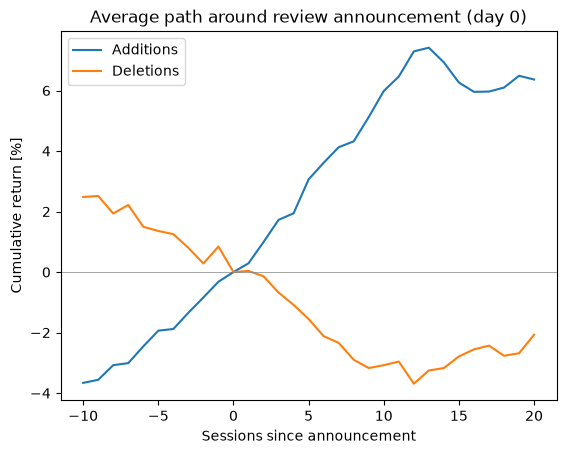

In [4]:
window = np.arange(-10, 21)


def event_paths(key):
    return [close[i, rv['announce'] + window] / close[i, rv['announce']] - 1
            for rv in reviews
            if 0 <= rv['announce'] - 10 and rv['announce'] + 20 < T
            for i in rv[key]]


events = pd.DataFrame({'Additions': np.mean(event_paths('adds'), axis=0),
                       'Deletions': np.mean(event_paths('drops'), axis=0)},
                      index=window)
ax = (events * 100).plot(title='Average path around review announcement (day 0)')
ax.set_xlabel('Sessions since announcement')
ax.set_ylabel('Cumulative return [%]')
_ = ax.axhline(0, color='gray', lw=.5)

The screener: predicting additions without peeking
--------------------------------------------------

The edge of this strategy lives or dies on **look-ahead bias**, so let's be explicit about
what may be known on decision day `t` (a Friday, after the close):

* **Prices and market caps up to day `t`'s close** — yes. We always trade at the _next_
  open, which _backtesting.py_ does for us anyway.
* **Current index membership** — yes, but only as produced by reviews whose changes are
  already in force (`membership` is consulted strictly by effective date; using today's
  constituent list throughout history is the classic survivorship mistake).
* **A review's add/drop lists** — only from its announcement date onward.
* **Future ranks, future announcements** — never. Before the cutoff we may only
  _extrapolate_ current ranks; a candidate can still drift out of the band, which is
  precisely the risk premium of entering early.

The screener walks the weekly decision days and looks for two setups, in order of priority:

1. **Announced additions** (between announcement and effective day): membership is already
   certain; the trade simply rides the index-tracker flows into the effective close.
2. **Predicted additions** (up to two weeks before the cutoff): any non-member ranking
   comfortably inside the automatic-entry band — rank ≤ 90 − `buffer` — is bought in
   anticipation. If the prediction fails (the stock leaves the band or isn't announced),
   the position is abandoned.

It also enforces the portfolio rules of this tutorial: **one stock at a time**, entries
decided **weekly**, and every window closed a few sessions after the effective day at the
latest — the strategy itself will additionally cap holding time at about a calendar month.

In [5]:
PRE_CUTOFF = 10      # start hunting this many sessions before a cutoff
FAIL_RANK = 100      # abandon a predicted candidate whose rank decays past this
POST_EFFECTIVE = 1   # sell into the trackers' buying: exit right after the effective day
MAX_WINDOW = 25      # absolute cap on any window's length, in sessions

cap = close * shares
rank_daily = np.empty((N, T), int)
order = np.argsort(-cap, axis=0)
rank_daily[order, np.arange(T)[None, :]] = np.arange(1, N + 1)[:, None]


def members_at(t):
    mem = initial_members
    for live_from, m in membership:
        if live_from > t:
            break
        mem = m
    return mem


def find_windows(buffer=2):
    """Return candidate windows [{'stock', 'start', 'end', 'kind'}, ...],
    at most one active at any time, entries decided on Fridays only."""
    windows = []
    busy_until = -1
    for t in np.flatnonzero(calendar.weekday == 4):        # weekly decisions
        if t <= busy_until:
            continue
        mem, stock = members_at(t), None
        rv = next((r for r in reviews if r['announce'] <= t < r['effective']), None)
        if rv:                                             # 1) an announced addition
            stock, kind = max(rv['adds'], key=lambda i: cap[i, t], default=None), 'announced'
        else:                                              # 2) a predicted addition
            rv = next((r for r in reviews if r['cutoff'] >= t), None)
            if rv and rv['cutoff'] - t <= PRE_CUTOFF:
                cands = [i for i in range(N)
                         if i not in mem and rank_daily[i, t] <= ADD_RANK - buffer]
                stock, kind = min(cands, key=lambda i: rank_daily[i, t], default=None), 'predicted'
        if stock is None:
            continue
        end = min(rv['effective'] + POST_EFFECTIVE, t + MAX_WINDOW, T - 3)
        if kind == 'predicted':
            if stock not in rv['adds']:                    # public from the announcement on
                end = min(end, rv['announce'] + 1)         # prediction failed → bail out
            failed = next((u for u in range(t + 1, min(rv['cutoff'], end))
                           if rank_daily[stock, u] > FAIL_RANK), None)
            if failed:
                end = min(end, failed)
        windows.append({'stock': stock, 'start': t, 'end': end, 'kind': kind})
        busy_until = end + 2
    return windows


windows = find_windows()
summary = pd.DataFrame(windows)
summary['ticker'] = [TICKERS[w['stock']] for w in windows]
print(f'{len(windows)} candidate windows, '
      f'{summary.kind.value_counts().to_dict()}, '
      f'longest {int((summary.end - summary.start).max())} sessions')
summary.tail()

42 candidate windows, {'predicted': 30, 'announced': 12}, longest 21 sessions


,stock,start,end,kind,ticker
37,192,2842,2863,predicted,ZXC
38,105,2917,2928,announced,JVN
39,92,2972,2993,predicted,QEKH
40,9,3047,3058,announced,DFIO
41,148,3112,3123,announced,TOJ


One stock at a time, one data series: a stitched tape
-----------------------------------------------------

_Backtesting.py_ works on a single instrument, while our strategy hops between stocks.
Because it holds **at most one position at a time**, we can splice the candidates'
OHLC data into one continuous "tape": each window contributes its stock's bars, plus a
`Signal` column (1 while we want to be long) and a `Window` id. Two properties make this
rigorous rather than a hack:

* every segment is rescaled by a constant (so each candidate trades near 100 at entry),
  which leaves every return within the segment unchanged, and
* no trade ever spans a splice — windows end (`Signal` → 0) at least two sessions before
  their segment does, so positions are always closed on the same stock they were opened
  on, and the price jumps at segment boundaries only ever occur while flat
  (both asserted below).

The one casualty is the `Buy & Hold Return` statistic, which on a stitched tape measures
an arbitrary chain of stocks — ignore it.

In [6]:
def build_tape(windows):
    parts, seg_id, prev_end = [], np.zeros(T, int), -1
    for k, w in enumerate(windows):
        lo = prev_end + 1
        hi = T - 1 if k == len(windows) - 1 else min(w['end'] + 2, T - 1)
        s = w['stock']
        scale = 100 / close[s, w['start']]
        part = pd.DataFrame({'Open': open_[s, lo:hi + 1] * scale,
                             'High': high[s, lo:hi + 1] * scale,
                             'Low': low[s, lo:hi + 1] * scale,
                             'Close': close[s, lo:hi + 1] * scale,
                             'Volume': volume[s, lo:hi + 1] / scale,
                             'Signal': 0, 'Window': -1},
                            index=calendar[lo:hi + 1])
        part.iloc[w['start'] - lo:w['end'] - lo, part.columns.get_loc('Signal')] = 1
        part.iloc[w['start'] - lo:w['end'] - lo, part.columns.get_loc('Window')] = k
        seg_id[lo:hi + 1] = k
        parts.append(part)
        prev_end = hi
    return pd.concat(parts), seg_id


tape, seg_id = build_tape(windows)
assert tape.index.equals(calendar)
tape[tape.Signal == 1].head()

,Open,High,Low,Close,Volume,Signal,Window
2014-05-23,100.230210,101.054387,99.299589,100.000000,330264.464605,1,0
2014-05-26,100.013678,100.985429,99.052525,100.039380,333557.051547,1,0
2014-05-27,100.480392,100.484369,100.058182,100.307451,918534.874691,1,0
2014-05-28,100.306383,102.344132,99.798072,102.030578,176745.444567,1,0
2014-05-29,102.355425,102.822900,100.258490,100.926580,387413.050220,1,0


The strategy
------------

With the screening logic baked into the tape, the strategy class is short. It buys at
Monday's open whenever a fresh window switched `Signal` on at the Friday close, and exits
when the window says so (effective day passed, or the candidacy failed) — **or when the
position is about `hold_limit` sessions old**, whichever comes first. The default of 21
sessions is roughly one calendar month, this strategy's maximum patience; a `Window` id
guard prevents re-entering a window it has already traded.

In [7]:
from backtesting import Backtest, Strategy


class IndexInclusion(Strategy):
    hold_limit = 21                    # max sessions in a position (≈ 1 calendar month)

    def init(self):
        self._last_window = -1

    def next(self):
        if self.position:
            held = len(self.data) - 1 - self.trades[-1].entry_bar
            if not self.data.Signal[-1] or held + 1 >= self.hold_limit:
                self.position.close()
        elif self.data.Signal[-1]:
            window = int(self.data.Window[-1])
            if window != self._last_window:
                self._last_window = window
                self.buy()


bt = Backtest(tape, IndexInclusion, cash=100_000, commission=.002, finalize_trades=True)
stats = bt.run()
stats

Loading BokehJS ...

Start                     2014-01-01 00:00:00
End                       2025-12-31 00:00:00
Duration                   4382 days 00:00:00
Exposure Time [%]                    24.81635
Equity Final [$]                2620139.19631
Equity Peak [$]                 2718888.22504
Commissions [$]                  132146.19348
Return [%]                          2520.1392
Buy & Hold Return [%]                51.86097
Return (Ann.) [%]                    30.06322
Volatility (Ann.) [%]                 23.6916
CAGR [%]                             20.66046
Sharpe Ratio                          1.26894
Sortino Ratio                         2.91485
Calmar Ratio                          0.96268
Alpha [%]                          2517.34683
Beta                                  0.05384
Max. Drawdown [%]                   -31.22866
Avg. Drawdown [%]                    -3.76461
Max. Drawdown Duration      467 days 00:00:00
Avg. Drawdown Duration       53 days 00:00:00
# Trades                          

Exposure of ~25%, a high win rate, an average trade of several percent, every position
closed within a month — the anatomy of an event-driven strategy. But before admiring the
headline return, let's verify the trades honour every rule we promised — and, since we
know this market's physics exactly, decompose each trade into the index-flow effect we
planted versus everything else. The counterfactual is one line: reprice the same trade in
a world where the flow perturbations (`delta`) never happened.

In [8]:
trades = stats['_trades'].copy()
trades['Ticker'] = [TICKERS[windows[seg_id[b]]['stock']] for b in trades.EntryBar]
trades['Kind'] = [windows[seg_id[b]]['kind'] for b in trades.EntryBar]

assert (seg_id[trades.EntryBar] == seg_id[trades.ExitBar]).all()   # no trade spans a splice
assert (trades.EntryBar.values[1:] >= trades.ExitBar.values[:-1]).all()  # one at a time
assert (trades.ExitBar - trades.EntryBar <= IndexInclusion.hold_limit).all()  # ≤ ~1 month

cum = np.cumsum(delta, axis=1)                 # cumulative index-flow price perturbation
stock_of = np.array([windows[seg_id[b]]['stock'] for b in trades.EntryBar])
entry, exit_ = trades.EntryBar.to_numpy(), trades.ExitBar.to_numpy()
no_flows = (1 + trades.ReturnPct) * np.exp(cum[stock_of, entry - 1]
                                           - cum[stock_of, exit_ - 1]) - 1
trades['FlowsPct'] = trades.ReturnPct - no_flows

trades.groupby('Kind').agg(**{'Trades': ('ReturnPct', 'count'),
                              'Avg return': ('ReturnPct', 'mean'),
                              '… from index flows': ('FlowsPct', 'mean'),
                              'Win rate': ('ReturnPct', lambda s: (s > 0).mean())})

,Trades,Avg return,… from index flows,Win rate
Kind,,,,
announced,12,0.069688,0.035865,0.833333
predicted,30,0.094114,0.048609,0.800000


The machinery captures almost exactly the ~5% effect we planted — announced entries a
little less, since the ramp is already underway by the time they get in. The rest of the
average trade is our synthetic candidates' _own momentum_: the screener, by construction,
selects stocks that have just risen into the entry band, and in this toy market the
persistent drifters that do so keep drifting. Real markets are under no obligation to pay
you that part — when you rerun this on real data, it's the flow component, not the
headline average, that you should sanity-check against the index-effect literature.

In [9]:
trades[['Ticker', 'Kind', 'EntryTime', 'ExitTime', 'ReturnPct']].tail(10)

,Ticker,Kind,EntryTime,ExitTime,ReturnPct
32,IUP,predicted,2023-05-22,2023-06-20,0.061510
33,AIP,predicted,2023-08-21,2023-09-19,0.483699
34,QDFU,predicted,2023-11-20,2023-12-19,0.119017
35,TBQ,announced,2024-03-04,2024-03-19,-0.044678
36,RLM,predicted,2024-05-27,2024-06-25,0.023284
37,ZXC,predicted,2024-11-25,2024-12-24,0.133819
38,JVN,announced,2025-03-10,2025-03-25,0.011739
39,QEKH,predicted,2025-05-26,2025-06-24,-0.029213
40,DFIO,announced,2025-09-08,2025-09-23,0.117499
41,TOJ,announced,2025-12-08,2025-12-23,0.074716


In [10]:
bt.plot()

GridPlot(id='p1306', ...)

How long should we hold on?
---------------------------

Our exit is "just after the effective day, but at most `hold_limit` sessions". Optimizing
that single knob shows the trade-off: exit too early and the position misses the
tracker-flow ramp it was opened for; the payoff plateaus once the holding period is long
enough to reach the effective day, and the post-effective reversion means there is no
reward for overstaying.

In [11]:
_, heatmap = bt.optimize(hold_limit=range(5, 26, 2),
                         maximize='Equity Final [$]', return_heatmap=True)
heatmap

hold_limit
5             1.740453e+05
7             2.521757e+05
9             3.401999e+05
11            4.991259e+05
13            7.201420e+05
15            9.293268e+05
17            1.018154e+06
19            1.652556e+06
21            2.620139e+06
23            2.620139e+06
25            2.620139e+06
Name: Equity Final [$], dtype: float64

The other lever is the **prediction buffer** — how deep inside the entry band (rank
≤ 90 − buffer) a stock must be before we bet on its inclusion ahead of the cutoff.
A deeper rank makes the prediction safer but can only forfeit opportunities; whether that
trade-off pays is an empirical question. This knob lives in the screener, upstream of the
`Backtest`, so we rerun the whole pipeline for each value — a useful pattern whenever part
of a strategy (cross-sectional screening, universe selection) happens outside a single
instrument's price series:

In [12]:
sensitivity = {}
for buffer in (0, 2, 4, 6):
    tp, _ = build_tape(find_windows(buffer=buffer))
    st = Backtest(tp, IndexInclusion, cash=100_000,
                  commission=.002, finalize_trades=True).run()
    sensitivity[ADD_RANK - buffer] = st[['# Trades', 'Win Rate [%]', 'Avg. Trade [%]',
                                         'Return [%]', 'Return (Ann.) [%]']]
pd.DataFrame(sensitivity).T.rename_axis('Entry rank ≤')

,# Trades,Win Rate [%],Avg. Trade [%],Return [%],Return (Ann.) [%]
Entry rank ≤,,,,,
90,42,83.333333,8.413437,2855.454186,31.32998
88,42,80.952381,8.102553,2520.139196,30.06322
86,41,78.04878,7.684001,1968.405648,27.611424
84,41,80.487805,7.049781,1524.17837,25.152181


Here the answer is: it doesn't. The chosen candidate usually sits _deep_ inside the entry
band — like the famous real-world cases, its addition is all but certain — so demanding
extra margin only skips trades without improving the ones taken. The buffer would earn its
keep in a market where you must settle for shallower candidates or position weeks earlier;
prediction risk, like everything else here, is a dial to measure rather than assume.

From toy market to real market
------------------------------

Everything above transfers to real data by replacing the simulator with actual
point-in-time series; before you do, mind the gaps between this toy and reality:

* **The edge was planted here.** We injected a 1990s-sized index effect into the simulated
  prices, so the backtest _demonstrates the machinery_, not the current profitability of
  the trade. On today's S&P 500 the announcement-to-effective effect is mostly gone
  (see [Greenwood & Sammon](https://www.nber.org/papers/w30748)); smaller and
  less-arbitraged indices retain more of it.
* **Point-in-time everything.** You need historical constituent lists (or a replay of the
  rulebook, as here), shares outstanding *as reported at the time*, and the provider's
  announcement timestamps. Free float and shares data arrive with reporting lags —
  assume you know them a few days late, as index providers themselves do.
* **Committee indices are only semi-predictable.** For the S&P 500, screening produces an
  eligibility shortlist, not a certainty — position sizing and diversification across
  candidates matter more there.
* **Crowding.** You will be trading against professional index arbitrageurs; assume
  realistic commissions and slippage (the `commission=.002` here is a start), and expect
  the pre-positioning to begin earlier every year.
* **Extensions to try**: shorting predicted deletions (borrow costs allowing); hedging
  market beta with index futures so only the inclusion premium remains; trading the
  post-effective *reversion*; or porting the screener to the Nasdaq-100's December
  reconstitution, whose top-75 rule this notebook's `find_windows()` can express almost
  verbatim.

Learn more by exploring further
[examples](https://kernc.github.io/backtesting.py/doc/backtesting/index.html#tutorials)
or find more framework options in the
[full API reference](https://kernc.github.io/backtesting.py/doc/backtesting/index.html#header-submodules).